# Populate HexMazeThetaV1 for all hex maze sessions

Runs the full LFP to theta pipeline for all sessions that have ephys data and exist in `HexMazeBlock`, then populates `HexMazeThetaV1`.

Pipeline steps (handled automatically by `setup_theta_pipeline`):
1. LFP lowpass filter matched to the session's actual raw sampling rate (fetched from the database)
2. LFP electrode group (all electrodes from sort groups, excluding bad channels)
3. LFP filtered and downsampled to ~1000 Hz (`LFPV1`) — **~2 hours per session**
4. Theta bandpass filter (5–11 Hz) matched to actual LFP output rate
5. Theta-band LFP (`LFPBandV1`)
6. Analytic signal, phase, and power saved to NWB (`HexMazeThetaV1`)

In [1]:
import datajoint as dj
import numpy as np
import pandas as pd

import spyglass.common as sgc
import spyglass.lfp as lfp
import spyglass.spikesorting.v1 as sgs
# Berke lab IM-* sessions were sorted with spikesorting v1
# Frank lab sessions (e.g. Toby) have sort groups in spikesorting v0
from spyglass.spikesorting.v0.spikesorting_recording import SortGroup as SortGroupV0
from spyglass.lfp.analysis.v1.lfp_band import LFPBandV1, LFPBandSelection

from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import HexMazeThetaV1

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-07-02 15:16:54,252][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

## Check current state of tables

In [ ]:
# Pick the right SortGroup table for a session based on its nwb file name
# Berke lab IM-* sessions live in spikesorting v1 (sgs.SortGroup)
# Frank lab sessions (e.g. Toby) live in spikesorting v0 (SortGroupV0)
def sort_group_table(nwb_file_name):
    """Return the SortGroup table (v1 or v0) that holds this session's sort groups."""
    return sgs.SortGroup if nwb_file_name.startswith("IM-") else SortGroupV0


# The run-epoch interval(s) to process for a session.
# Berke lab IM-* sessions have a single run epoch: "00_r1"
# Frank lab sessions have 4 or 5 run epochs:
# epoch 1: "01_r1", epoch 3: "03_r2", epoch 5: "05_r3", epoch 7: "07_r4", epoch 9: "09_r5"
# In both cases we just look up the run interval of every epoch that has a HexMazeBlock from TaskEpoch
def get_run_intervals(nwb_file_name):
    """Return the run-epoch interval_list_name(s) that contain hex maze blocks."""
    hex_epochs = sorted(set((HexMazeBlock & {"nwb_file_name": nwb_file_name}).fetch("epoch")))
    return [
        (sgc.TaskEpoch & {"nwb_file_name": nwb_file_name, "epoch": e}).fetch1("interval_list_name")
        for e in hex_epochs
    ]


# All sessions in HexMazeBlock that also have ephys data (a SortGroup entry)
all_hex_sessions = sorted(set(HexMazeBlock.fetch("nwb_file_name")))
files = sorted(
    f for f in all_hex_sessions if len(sort_group_table(f) & {"nwb_file_name": f}) > 0
)

# Expand each ephys session into one (session, run interval) job per run epoch.
# This is the unit of work for the whole pipeline below.
jobs = [
    {"nwb_file_name": f, "interval_list_name": iv}
    for f in files
    for iv in get_run_intervals(f)
]

######## START ADDED FOR LILY -STEPH ####### !!!!!!
# For now, only process Lily sessions
jobs = [j for j in jobs if j["nwb_file_name"].startswith("Lily")]

print(f"{len(jobs)} Lily job(s):")
for j in jobs:
    print(f"  {j['nwb_file_name']}  [{j['interval_list_name']}]")
############## END ADDED

print(f"Found {len(files)} hex maze sessions with ephys, {len(jobs)} epochs:")
for f in files:
    intervals = [j["interval_list_name"] for j in jobs if j["nwb_file_name"] == f]
    print(f"  {f}: {intervals}")

# What's already populated
print(f"\nHexMazeThetaV1 already has {len(HexMazeThetaV1())} entries:")
display(HexMazeThetaV1())

15 Lily job(s):
  Lily20251217_.nwb  [01_r1]
  Lily20251217_.nwb  [03_r2]
  Lily20251217_.nwb  [05_r3]
  Lily20251217_.nwb  [07_r4]
  Lily20251217_.nwb  [09_r5]
  Lily20251221_.nwb  [01_r1]
  Lily20251221_.nwb  [03_r2]
  Lily20251221_.nwb  [05_r3]
  Lily20251221_.nwb  [07_r4]
  Lily20251221_.nwb  [09_r5]
  Lily20251224_.nwb  [01_r1]
  Lily20251224_.nwb  [03_r2]
  Lily20251224_.nwb  [05_r3]
  Lily20251224_.nwb  [07_r4]
  Lily20251224_.nwb  [09_r5]
Found 36 hex maze sessions with ephys, 15 epochs:
  BraveLu20240617_.nwb: []
  BraveLu20240622_.nwb: []
  IM-1478_20220719_.nwb: []
  IM-1478_20220720_.nwb: []
  IM-1478_20220724_.nwb: []
  IM-1478_20220725_.nwb: []
  IM-1478_20220726_.nwb: []
  IM-1478_20220727_.nwb: []
  IM-1594_20230725_.nwb: []
  IM-1594_20230726_.nwb: []
  IM-1594_20230727_.nwb: []
  IM-1594_20230728_.nwb: []
  IM-1871_20250731_.nwb: []
  IM-1871_20250801_.nwb: []
  IM-1871_20250802_.nwb: []
  IM-1871_20250803_.nwb: []
  IM-1871_20250804_.nwb: []
  IM-1871_20250805_.nwb: 

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform,"theta_phase_object_id instantaneous phase [0, 2π] in radians",theta_power_object_id instantaneous power (amplitude²)
15f98b82-6683-657e-6e4c-589b020c2632,Theta 5-11 Hz,1000,Toby20250318_.nwb,07_r4_noPreTrialTimes,100,Toby20250318_A8P6GR5X10.nwb,a2cb64b9-8bd7-40af-a244-bd9c0fd15769,56ca36b6-ee74-40bb-a51a-19f9547ff903,e8181638-0b9d-41b7-bf7e-536e2521f0f3
236edb91-f3f0-34bf-eba7-363f9969a6c5,Theta 5-11 Hz,1034,IM-1594_20230725_.nwb,00_r1,1034,IM-1594_20230725_ZJNDWOFQ1H.nwb,73a5a509-c2d5-43d7-b977-37c06a7e44cf,5c73d063-6fc1-494b-b7fd-15362e5f83d0,3bf9bdf9-b8bf-47f9-a07d-7f7482289f09
24f20c68-7544-a493-612f-85c875ea3428,Theta 5-11 Hz,1034,IM-1871_20250803_.nwb,00_r1,1034,IM-1871_20250803_OVYOCWOQ5S.nwb,6c1f231a-9385-4c3f-9816-48cdfd9cb771,f9051f1c-cae8-4d50-88a5-57c27026880b,2e8b8bbc-66f6-46b4-bc1c-026e64100684
2c09f8f8-bac9-9db2-787e-10f412ee61e7,Theta 5-11 Hz,1000,IM-1871_20250731_.nwb,00_r1,1000,IM-1871_20250731_RSGW8NLGC3.nwb,3cf56f19-884c-4398-927b-c7842b3b8e5f,2969c25f-1767-4ca7-b287-b8b4eb417192,34fcda86-33b2-40bd-ad5c-c19d4603dd02
3acae88c-c8e9-a3e4-4de3-cb2e318f2ec2,Theta 5-11 Hz,1000,IM-1947_20260402_.nwb,00_r1,1000,IM-1947_20260402_SKMN3BOLM7.nwb,638bcec7-623f-4eff-ae22-17694a0bc84b,20af5e95-2583-4054-baee-12f92e988823,65d89e60-2f66-4872-a313-46dbb8afc8ff
4b852aa8-4844-5c17-261a-97bac2728ed1,Theta 5-11 Hz,1000,Toby20250327_.nwb,07_r4_noPreTrialTimes,100,Toby20250327_0PIXJMW5GA.nwb,cf9415c5-3960-458a-bae0-fb637cc87dfb,84679245-3a95-488f-a42e-2ee93c929791,c8804c78-29a8-40c1-843e-c37d3db0ce01
578f3c15-ce09-b3e8-39e8-f06120fe8570,Theta 5-11 Hz,1000,IM-1478_20220727_.nwb,00_r1,1000,IM-1478_20220727_R38TB49GRY.nwb,dc07fcfd-357e-4b9d-b32b-7fb4d0216921,de60167a-aa17-45ab-aa88-90919020bd10,5235e3c2-2090-4c24-bc53-d4f1fe12a455
595c99be-c433-697a-07a1-8727c8aacbc1,Theta 5-11 Hz,1000,IM-1478_20220720_.nwb,00_r1,1000,IM-1478_20220720_M4B8NY7XMF.nwb,a689ffcf-a0ca-4368-9ffc-df66312e71b1,80f8a467-d1c4-450e-b900-89a9c2d58103,8303f3cf-7531-4ec4-9de8-ef056035dbad
59b970f1-a77c-d2ce-c36b-35401958e0f6,Theta 5-11 Hz,1000,IM-1941_20260207_.nwb,00_r1,1000,IM-1941_20260207_L34O04SV1M.nwb,964a2e3e-2a07-4a78-a80f-482e2cadf4d5,eac1b34e-109d-4904-b3b2-4d3cf19b24d4,99d9b096-eb14-49ab-b9b3-9dfa83469f93
5b6ffc5f-eb09-ad3c-be6e-c95ae0ca462f,Theta 5-11 Hz,1034,IM-1594_20230728_.nwb,00_r1,1034,IM-1594_20230728_O4U0BP658F.nwb,372e5bc8-8af8-41aa-bf09-14cf1e9a0751,88312fbd-6707-4298-99f2-01354fd57b3a,6b1c92f6-3f32-4f84-b3a1-2095a4910184


## Helper to get electrode IDs for a session

Uses all electrodes from sort groups

In [3]:
def get_electrode_ids(nwb_file_name):
    """Get electrode IDs for LFP processing from sort groups (excludes bad channels).

    Uses the v1 or v0 SortGroup table depending on the session (see sort_group_table).
    """
    # IM-* -> spikesorting v1, Frank lab -> spikesorting v0
    SortGroupTable = sort_group_table(nwb_file_name)
    electrodes_df = pd.DataFrame(
        (
            SortGroupTable * SortGroupTable.SortGroupElectrode
            & {"nwb_file_name": nwb_file_name}
        ).fetch(as_dict=True)
    )
    return electrodes_df["electrode_id"].unique().tolist()


# Confirm it works on a known session
test_file = sorted(files)[0]
test_electrodes = get_electrode_ids(test_file)
print(f"{test_file}: {len(test_electrodes)} electrodes")
print(test_electrodes)

BraveLu20240617_.nwb: 128 electrodes
[0, 1, 2, 3, 4, 5, 6, 7, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8, 9, 10, 11, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 12, 13, 14, 15, 120, 121, 122, 123, 124, 125, 126, 127, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


## Pipeline setup — loop through all sessions

Calls `setup_theta_pipeline` for each session not yet in `LFPBandSelection`.
The `LFPV1` populate inside takes ~2 hours per session. The loop is safe to interrupt
and restart — all inserts use `skip_duplicates`, and the recovery cell below reloads
any keys already in the database.

In [4]:
# Settings shared across all sessions (the interval list name now comes from each job)
THETA_FILTER_NAME = "Theta 5-11 Hz"
THETA_BAND_EDGES = [4, 5, 11, 12]

# Keyed by (nwb_file_name, interval_list_name) since a session can have several run epochs
lfp_band_keys = {}

# In LFPBandSelection the run interval is stored as target_interval_list_name
job_restrictions = [
    {"nwb_file_name": j["nwb_file_name"], "target_interval_list_name": j["interval_list_name"]}
    for j in jobs
]

# Recover any LFPBandSelection keys already in the DB (safe after kernel restart)
for row in (
    LFPBandSelection & job_restrictions & {"filter_name": THETA_FILTER_NAME}
).fetch("KEY", as_dict=True):
    key = (row["nwb_file_name"], row["target_interval_list_name"])
    lfp_band_keys[key] = row

print(f"Recovered {len(lfp_band_keys)} LFP band key(s) already in DB:")
for nwb, interval in sorted(lfp_band_keys):
    print(f"  {nwb}  [{interval}]")

Recovered 0 LFP band key(s) already in DB:


### Run setup_theta_pipeline for each session not yet in LFPBandSelection

In [ ]:
todo = [
    j for j in jobs
    if (j["nwb_file_name"], j["interval_list_name"]) not in lfp_band_keys
]
print(f"{len(lfp_band_keys)} job(s) already have LFPBandSelection keys.")
print(f"{len(todo)} job(s) still need setup_theta_pipeline:")
for j in todo:
    print(f"  {j['nwb_file_name']}  [{j['interval_list_name']}]")

for j in todo:
    nwb_file_name = j["nwb_file_name"]
    interval_list_name = j["interval_list_name"]
    # One LFP electrode group per file (same electrodes for all of its run epochs);
    # setup_theta_pipeline skips duplicates, so reusing the name across intervals is fine.
    lfp_group_name = nwb_file_name.replace("_.nwb", "_lfp")
    electrode_ids = get_electrode_ids(nwb_file_name)
    print(f"\nSetting up {nwb_file_name} [{interval_list_name}] ({len(electrode_ids)} electrodes)...")
    lfp_band_keys[(nwb_file_name, interval_list_name)] = HexMazeThetaV1.setup_theta_pipeline(
        nwb_file_name=nwb_file_name,
        lfp_electrode_group_name=lfp_group_name,
        electrode_ids=electrode_ids,
        interval_list_name=interval_list_name,
        theta_filter_name=THETA_FILTER_NAME,
        theta_band_edges=THETA_BAND_EDGES,
    )
    print(f"  Done. Key: {lfp_band_keys[(nwb_file_name, interval_list_name)]}")

print(f"\n{len(lfp_band_keys)} job(s) ready for LFPBandV1 populate.")

0 job(s) already have LFPBandSelection keys.
15 job(s) still need setup_theta_pipeline:
  Lily20251217_.nwb  [01_r1]
  Lily20251217_.nwb  [03_r2]
  Lily20251217_.nwb  [05_r3]
  Lily20251217_.nwb  [07_r4]
  Lily20251217_.nwb  [09_r5]
  Lily20251221_.nwb  [01_r1]
  Lily20251221_.nwb  [03_r2]
  Lily20251221_.nwb  [05_r3]
  Lily20251221_.nwb  [07_r4]
  Lily20251221_.nwb  [09_r5]
  Lily20251224_.nwb  [01_r1]
  Lily20251224_.nwb  [03_r2]
  Lily20251224_.nwb  [05_r3]
  Lily20251224_.nwb  [07_r4]
  Lily20251224_.nwb  [09_r5]

Setting up Lily20251217_.nwb [01_r1] (384 electrodes)...


[15:17:55][INFO] Spyglass: Successfully created/updated LFPElectrodeGroup Lily20251217_.nwb, Lily20251217_lfp with 384 electrodes.
INFO:spyglass:Successfully created/updated LFPElectrodeGroup Lily20251217_.nwb, Lily20251217_lfp with 384 electrodes.
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extensio

  Done. Key: {'lfp_merge_id': UUID('c381769f-4228-af99-ed15-ff0e96fdb55a'), 'filter_name': 'Theta 5-11 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'Lily20251217_.nwb', 'target_interval_list_name': '01_r1', 'lfp_band_sampling_rate': 1000}

Setting up Lily20251217_.nwb [03_r2] (384 electrodes)...


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
[16:20:25][INFO] Spyglass: Writing new NWB file Lily20251217_PPNJWA7BA5.nwb
INFO:spyglass:Writing new NWB file Lily20251217_PPNJWA7BA5.nwb
[2026-07-02 16:20:36,226][WARNING]: Skipped checksum for file with hash: 3d424a29-1b01-5ff5

  Done. Key: {'lfp_merge_id': UUID('85d4e3e2-ef19-926b-a516-191d8a09e9b1'), 'filter_name': 'Theta 5-11 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'Lily20251217_.nwb', 'target_interval_list_name': '03_r2', 'lfp_band_sampling_rate': 1000}

Setting up Lily20251217_.nwb [05_r3] (384 electrodes)...


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
[17:22:09][INFO] Spyglass: Writing new NWB file Lily20251217_VUTQ5TTYP4.nwb
INFO:spyglass:Writing new NWB file Lily20251217_VUTQ5TTYP4.nwb
[2026-07-02 17:22:18,015][WARNING]: Skipped checksum for file with hash: 3d424a29-1b01-5ff5

  Done. Key: {'lfp_merge_id': UUID('1981a6c7-c84e-d4d7-21e7-f51dde7cb167'), 'filter_name': 'Theta 5-11 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'Lily20251217_.nwb', 'target_interval_list_name': '05_r3', 'lfp_band_sampling_rate': 1000}

Setting up Lily20251217_.nwb [07_r4] (384 electrodes)...


[18:16:14][INFO] Spyglass: Successfully created/updated LFPElectrodeGroup Lily20251217_.nwb, Lily20251217_lfp with 384 electrodes.
INFO:spyglass:Successfully created/updated LFPElectrodeGroup Lily20251217_.nwb, Lily20251217_lfp with 384 electrodes.
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extensio

## Populate LFPBandV1 and HexMazeThetaV1

Once all setup cells above have finished, populate the theta-band LFP and then the final table.
These are much faster than `LFPV1` — a few minutes each.

In [ ]:
# Populate LFPBandV1 for all jobs whose setup is complete
# (safe to re-run — already-populated entries are skipped)
for (nwb_file, interval), lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating LFPBandV1 for {nwb_file} [{interval}]...")
    LFPBandV1().populate(lfp_band_key)
    print(f"  done.")

display(LFPBandV1() & [{"nwb_file_name": f} for f in files])

In [ ]:
# Populate HexMazeThetaV1 for all jobs
# (computes analytic signal, phase, power and saves to analysis NWB)
for (nwb_file, interval), lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating HexMazeThetaV1 for {nwb_file} [{interval}]...")
    HexMazeThetaV1().populate(lfp_band_key)
    print(f"  done.")

display(HexMazeThetaV1() & [{"nwb_file_name": f} for f in files])

## Sanity check — fetch and plot for one session

In [ ]:
import matplotlib.pyplot as plt

# Pick a session
check_nwb = "IM-1478_20220725_.nwb"
theta_entry = HexMazeThetaV1() & {"nwb_file_name": check_nwb}

phase_df = theta_entry.fetch1_theta_phase()
power_df = theta_entry.fetch1_theta_power()

print(f"Theta phase shape: {phase_df.shape}  (n_timesteps × n_electrodes)")
print(f"Sampling rate: {1 / np.median(np.diff(phase_df.index)):.1f} Hz")
display(phase_df.head())
display(power_df.head())

[2026-04-27 00:36:56,752][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
[2026-04-27 00:36:56,764][WARNING]: Skipped checksum for file with hash: e579349a-10f1-9245-8daf-740f093ecb2a, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_IMSEN7F3KS.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

Theta phase shape: (4863702, 166)  (n_timesteps × n_electrodes)
Sampling rate: 1000.0 Hz


,electrode 56,electrode 57,electrode 58,electrode 59,electrode 60,electrode 61,electrode 62,electrode 63,electrode 65,electrode 66,...,electrode 245,electrode 246,electrode 247,electrode 249,electrode 250,electrode 251,electrode 252,electrode 253,electrode 254,electrode 255
time,,,,,,,,,,,,,,,,,,,,,
12.51145,1.803954,1.800348,1.795746,1.804022,1.808900,1.813796,1.840642,1.830888,1.811792,1.807629,...,4.932505,4.957762,4.940413,4.961965,4.962997,4.967390,4.968818,4.954723,4.977185,4.923812
12.51245,2.014603,2.004534,2.012398,2.023029,2.034072,2.039138,2.091155,2.080769,2.027024,2.018510,...,5.132389,5.183035,5.151480,5.190880,5.193172,5.197129,5.203116,5.178955,5.225401,5.109177
12.51345,2.038214,2.022581,2.031728,2.043386,2.047981,2.060242,2.107929,2.100635,2.050359,2.038523,...,5.144927,5.190217,5.159825,5.196642,5.208997,5.210786,5.212489,5.182513,5.232822,5.109343
12.51445,2.209875,2.199929,2.217119,2.218400,2.236254,2.247493,2.309208,2.297232,2.245212,2.223309,...,5.322615,5.384737,5.348518,5.398500,5.404338,5.406505,5.414885,5.386965,5.454922,5.275035
12.51545,2.237418,2.213537,2.228030,2.244126,2.261159,2.278617,2.331406,2.321190,2.261084,2.238590,...,5.336228,5.399613,5.356945,5.420271,5.416862,5.424143,5.431996,5.397783,5.465363,5.266389


,electrode 56,electrode 57,electrode 58,electrode 59,electrode 60,electrode 61,electrode 62,electrode 63,electrode 65,electrode 66,...,electrode 245,electrode 246,electrode 247,electrode 249,electrode 250,electrode 251,electrode 252,electrode 253,electrode 254,electrode 255
time,,,,,,,,,,,,,,,,,,,,,
12.51145,21654.132429,23660.154219,21887.419646,22933.609489,24608.931101,27635.848459,29774.963460,31994.602629,17976.505479,19782.432879,...,85917.324274,113948.652040,101447.905681,30308.592398,64536.057407,62377.852841,97019.745498,113935.441193,154890.315374,68691.510937
12.51245,7029.448625,7750.964745,7095.142793,7562.312199,8011.907147,9074.041646,9712.823685,10491.240320,5610.580060,6536.562030,...,26198.561545,34314.376005,29486.908105,9131.850958,19753.890080,18863.769335,28816.833432,31629.962669,44041.136261,19524.609178
12.51345,7112.448762,7980.289580,7299.127927,7721.976382,8362.623282,9573.441187,10328.058606,10997.430757,5754.355350,6734.768710,...,26316.301666,34166.698238,28468.250276,9343.239217,19775.275254,19063.372138,28534.397870,30413.290135,42076.559883,18090.827053
12.51445,4275.351594,4854.653610,4411.224834,4846.912853,5312.082408,6122.613820,6676.482454,7108.300842,3323.705967,4125.603947,...,14921.305427,19512.249257,15098.971476,5503.730146,11358.550734,10969.549355,16106.259576,15596.666399,22312.518697,8785.994727
12.51545,4396.641750,4909.952239,4503.873490,4978.563150,5447.117208,6396.471543,7078.801969,7485.637861,3376.392214,4172.352944,...,14772.705769,19241.866663,14359.588867,5449.462320,11351.192514,11159.774262,15858.721497,14798.019310,20960.284861,7981.229464


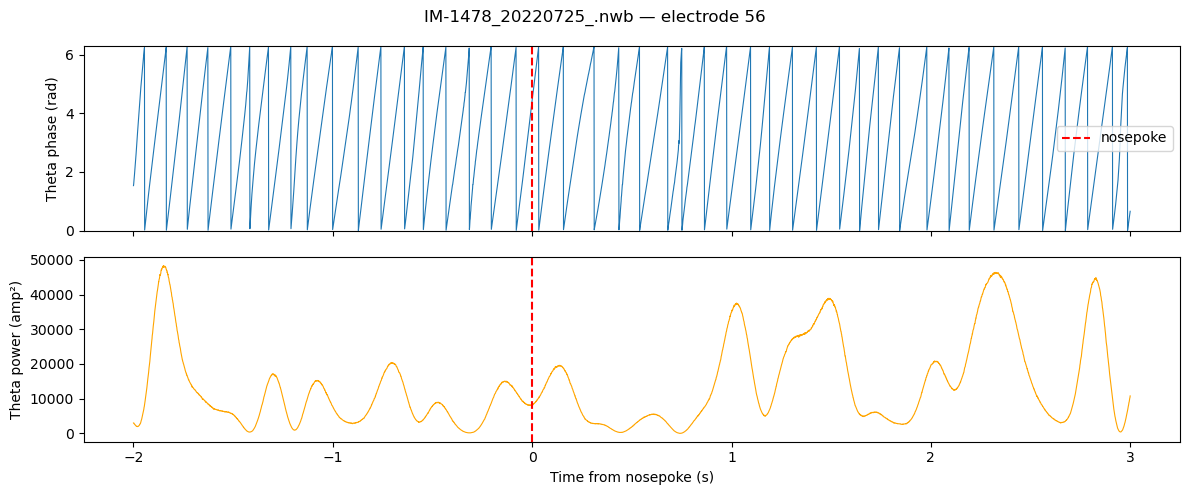

In [12]:
# Quick plot: theta phase and power for one electrode over a 5-second window
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock

# Grab a nosepoke time as a reference point
poke_intervals = (HexMazeBlock.Trial & {"nwb_file_name": check_nwb}).fetch("poke_interval")
poke_time = poke_intervals[5][0]  # end of trial 5 (nosepoke)
t0, t1 = poke_time - 2, poke_time + 3

# Pick the first electrode column for plotting
electrode_col = phase_df.columns[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

window_phase = phase_df.loc[t0:t1, electrode_col]
window_power = power_df.loc[t0:t1, electrode_col]

axes[0].plot(window_phase.index - poke_time, window_phase, lw=0.8)
axes[0].axvline(0, color="r", linestyle="--", label="nosepoke")
axes[0].set_ylabel("Theta phase (rad)")
axes[0].set_ylim(0, 2 * np.pi)
axes[0].legend()

axes[1].plot(window_power.index - poke_time, window_power, lw=0.8, color="orange")
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_ylabel("Theta power (amp²)")
axes[1].set_xlabel("Time from nosepoke (s)")

fig.suptitle(f"{check_nwb} — {electrode_col}")
plt.tight_layout()
plt.show()